<div style='background: linear-gradient(135deg, #667eea 0%, #b1d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Merge datasets</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

<style>
    /* Style global */
    body {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    }
    
    /* Headers stylés */
    h1, h2, h3, h4 {
        font-weight: 700;
    }
    
    /* Sections colorées */
    .section-header {
        background: linear-gradient(90deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 30px 0 20px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.2);
    }
    
    .info-box {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .warning-box {
        background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .success-box {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    /* Badges */
    .badge {
        display: inline-block;
        padding: 8px 15px;
        border-radius: 20px;
        font-size: 14px;
        font-weight: 600;
        margin: 5px;
    }
    
    .badge-primary {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
    }
    
    .badge-success {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        color: white;
    }
    
    .badge-warning {
        background: linear-gradient(135deg, #fa709a 0%, #fee140 100%);
        color: white;
    }
    
    /* Dividers */
    .divider {
        height: 3px;
        background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
        border: none;
        margin: 30px 0;
        border-radius: 5px;
    }
</style>

# Import package and config

In [12]:
import sys
from pathlib import Path

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.config import paths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import pycountry


## Configs

In [13]:
raw_dir=paths.DATA_DIR/"raw"
raw_dir

WindowsPath('C:/Users/HP/Desktop/temp/TODO/SEMESTRE_2/ML2/projet/data/raw')

In [14]:
root=paths.ROOT_DIR
with open(root / "configs" / "variables.yaml", "r") as f:
    config = yaml.safe_load(f)
    
sources = config["sources"]
print("Sources configurées :", list(sources.keys()))

Sources configurées : ['sante_wdi', 'sante_who', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment', 'securite_civil', 'securite_political']


# Main dataset

In [15]:
df_main=pd.read_csv(raw_dir/"Country-data.csv")
df_final = df_main.copy()
df_main.info()


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [16]:
df_main.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [17]:
len(df_main)

167

## Country Mapping 

In [18]:
def get_iso_code(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except (LookupError, AttributeError):
        return None


df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [19]:
# Dictionnaire de correspondance entre le dataset et la norme ISO
mapping_corrections = {
    'Brunei': 'Brunei Darussalam',
    'Cape Verde': 'Cabo Verde',
    'Congo, Dem. Rep.': 'Congo, The Democratic Republic of the',
    'Congo, Rep.': 'Congo',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Macedonia, FYR': 'North Macedonia',
    'Micronesia, Fed. Sts.': 'Micronesia, Federated States of',
    'Russia': 'Russian Federation',
    'St. Vincent and the Grenadines': 'Saint Vincent and the Grenadines',
    'Turkey': 'Türkiye'
}

# Application des corrections sur la colonne 'country'
df_final['country'] = df_final['country'].replace(mapping_corrections)

# Ré-exécution du mapping ISO
df_final['iso_code'] = df_final['country'].apply(get_iso_code)

In [20]:
# Vérification des valeurs manquantes après correction
missing_after = df_final[df_final['iso_code'].isna()]

if missing_after.empty:
    print("Succès total : Tous les pays ont désormais un code ISO Alpha-3.")
else:
    print(f"Il reste encore des anomalies pour : {missing_after['country'].unique()}")

# Validation de la cohérence dimensionnelle
n_lignes = len(df_final)
n_uniques = df_final['iso_code'].nunique()

print(f"Nombre total de lignes : {n_lignes}")
print(f"Nombre de codes ISO uniques : {n_uniques}")

if n_lignes == n_uniques:
    print("L'intégrité référentielle est parfaite : un code unique par ligne.")

Succès total : Tous les pays ont désormais un code ISO Alpha-3.
Nombre total de lignes : 167
Nombre de codes ISO uniques : 167
L'intégrité référentielle est parfaite : un code unique par ligne.


In [21]:
df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG


# Santé wdi datasets

Les indicateurs de santé sont généralement collectés annuellement, mais certains pays peuvent avoir un décalage. Nous extrayons 2014, mais pour les données très sporadiques (comme le nombre de médecins), nous vérifierons la pertinence d'une fenêtre temporelle de 2012-2016.

In [23]:
wdi_conf = sources["sante_wdi"]
df_wdi = pd.read_csv(raw_dir / wdi_conf["file"])
# Renommage in-place des intitulés longs par les noms courts du YAML
df_wdi = df_wdi[df_wdi["Series"].isin(wdi_conf["variables"])].replace({"Series": wdi_conf["variables"]})

wdi_to_iso_final = {
    'Turkiye': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM',
    'Congo, Dem. Rep.': 'COD',
    'Congo, Rep.': 'COG',
    "Cote d'Ivoire": 'CIV',
    'St. Vincent and the Grenadines': 'VCT',
    'Yemen, Rep.': 'YEM',
    'Venezuela, RB': 'VEN',
    'Egypt, Arab Rep.': 'EGY',
    'Korea, Rep.': 'KOR',
    'Iran, Islamic Rep.': 'IRN',
    'Gambia, The': 'GMB',
    'Bahamas, The': 'BHS',
    'Lao PDR': 'LAO',
    # Ajouts pour combler les manques
    'Türkiye': 'TUR',
    'Turkey': 'TUR',
    'Micronesia, Fed. Sts.': 'FSM'
}

#  mapping automatique
df_wdi['iso_code'] = df_wdi['Country'].apply(get_iso_code)

#  Correction forcée pour les pays manquants
# On utilise map() sur la colonne 'Country' pour remplir les NaN de 'iso_code'
# si iso_code est vide pour un pays, on le complète automatiquement en cherchant le code ISO via le mapping wdi_to_iso_final basé sur la colonne Country
df_wdi['iso_code'] = df_wdi['iso_code'].fillna(df_wdi['Country'].map(wdi_to_iso_final))

#  Filtrage par intersection 
iso_reference = df_final['iso_code'].unique()
df_wdi = df_wdi[df_wdi['iso_code'].isin(iso_reference)].copy()


# --- DIAGNOSTIC DE VÉRIFICATION ---

iso_f = set(df_final['iso_code'].unique())
iso_w = set(df_wdi['iso_code'].unique())

print(f"Nombre de pays (Référentiel) : {len(iso_f)}")
print(f"Nombre de pays (WDI)         : {len(iso_w)}")
print(f"Intersection                 : {len(iso_f & iso_w)}")

if iso_f - iso_w:
    print(f"Codes toujours manquants     : {iso_f - iso_w}")
else:
    print("Succès : Les 167 pays sont désormais alignés.")

Nombre de pays (Référentiel) : 167
Nombre de pays (WDI)         : 167
Intersection                 : 167
Succès : Les 167 pays sont désormais alignés.


In [24]:
df_wdi.head(2)

,economy,series,Country,Series,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,iso_code
1,ZMB,SH.DYN.MORT,Zambia,child_mortality,62.6,60.2,57.1,55.2,54.7,53.5,52.5,50.4,49.5,49.1,ZMB
2,YEM,SH.DYN.MORT,"Yemen, Rep.",child_mortality,48.7,49.3,47.9,47.5,47.3,46.1,43.4,42.6,41.1,39.5,YEM


## Valeurs NA

### Description

In [25]:
# Filtrage 2014
df_2014 = df_wdi[['iso_code', 'Country', 'Series', 'YR2014']].copy()
df_2014['is_na'] = df_2014['YR2014'].isna()

# Statistiques par indicateur
stats_vars = df_2014.groupby('Series')['is_na'].agg(['sum', 'mean']).sort_values(by='sum', ascending=False)
stats_vars.columns = ['Nombre de NA', 'Proportion de NA']
stats_vars['Proportion de NA'] = stats_vars['Proportion de NA'].map('{:.1%}'.format)

print("Bilan des manquants par variable en 2014 :")
print(stats_vars)

Bilan des manquants par variable en 2014 :
                            Nombre de NA Proportion de NA
Series                                                   
physicians_per_1000                   57            34.1%
hiv_prevalence                        31            18.6%
health_expenditure_pct_gdp             1             0.6%
child_mortality                        0             0.0%
life_expectancy                        0             0.0%
maternal_mortality                     0             0.0%
tb_incidence                           0             0.0%
vaccination_dpt                        0             0.0%


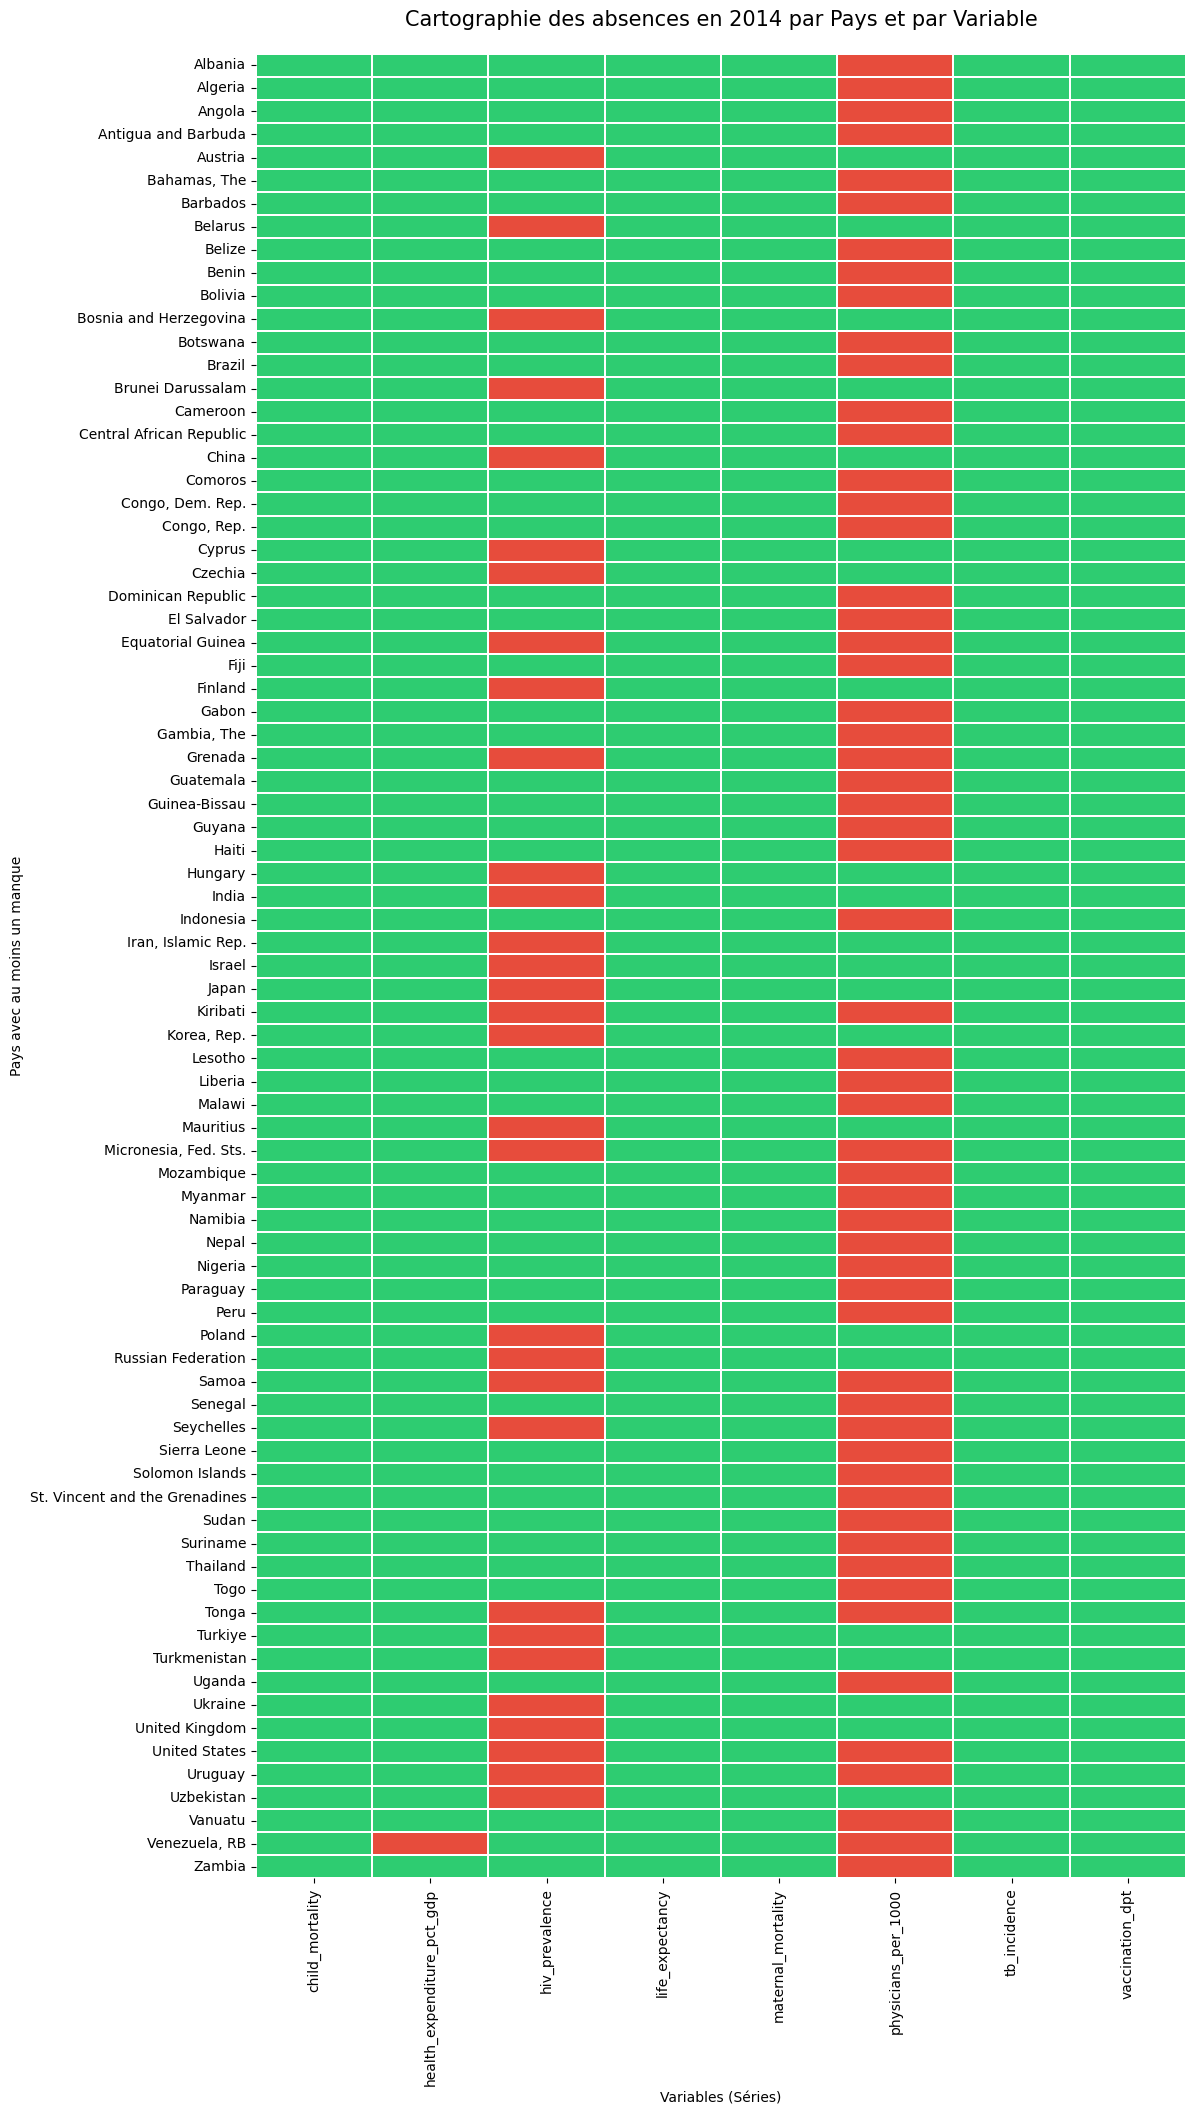

In [26]:
# Pivot pour avoir les Series en colonnes et les Countries en lignes
df_pivot_2014 = df_2014.pivot(index='Country', columns='Series', values='is_na')

# On ne garde que les pays qui ont au moins un NA
df_na_only = df_pivot_2014[df_pivot_2014.any(axis=1)]

plt.figure(figsize=(12, max(10, len(df_na_only) * 0.3)))
sns.heatmap(df_na_only, cmap=['#2ecc71', '#e74c3c'], cbar=False, linewidths=0.1)

# Légende personnalisée : Vert = Donnée présente, Rouge = NA
plt.title("Cartographie des absences en 2014 par Pays et par Variable", fontsize=15, pad=20)
plt.xlabel("Variables (Séries)")
plt.ylabel("Pays avec au moins un manque")
plt.show()

>Le taux de médecins (physicians_per_1000) a 34.1% de NA en 2014. 
Vérifions si élargir la fenêtre  permet de récupérer ces pays.

### Recherche sur 2015-2017

Pourquoi 2015-2017 ? car sont les plus proche de 2014 et le dataset demarre à 2014

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Conversion numérique sécurisée pour les colonnes cibles
years = ['YR2014', 'YR2015', 'YR2016', 'YR2017']
for yr in years:
    df_wdi[yr] = pd.to_numeric(df_wdi[yr], errors='coerce')

# Identification des NA avant traitement
initial_na = df_wdi['YR2014'].isna()

# Application du Backfilling (2015 -> 2016 -> 2017)
# combine_first remplit uniquement si la valeur à gauche est NaN
df_wdi['YR2014'] = df_wdi['YR2014'].fillna(df_wdi['YR2015']) \
                                   .fillna(df_wdi['YR2016']) \
                                   .fillna(df_wdi['YR2017'])

# Encodage du statut : 0 = Original, 1 = Récupéré, 2 = Absent
df_wdi['status'] = 0
# Si c'était NA au début ET que ce n'est plus NA maintenant -> Récupéré
df_wdi.loc[initial_na & df_wdi['YR2014'].notna(), 'status'] = 1
# Si c'est toujours NA -> Absent
df_wdi.loc[df_wdi['YR2014'].isna(), 'status'] = 2

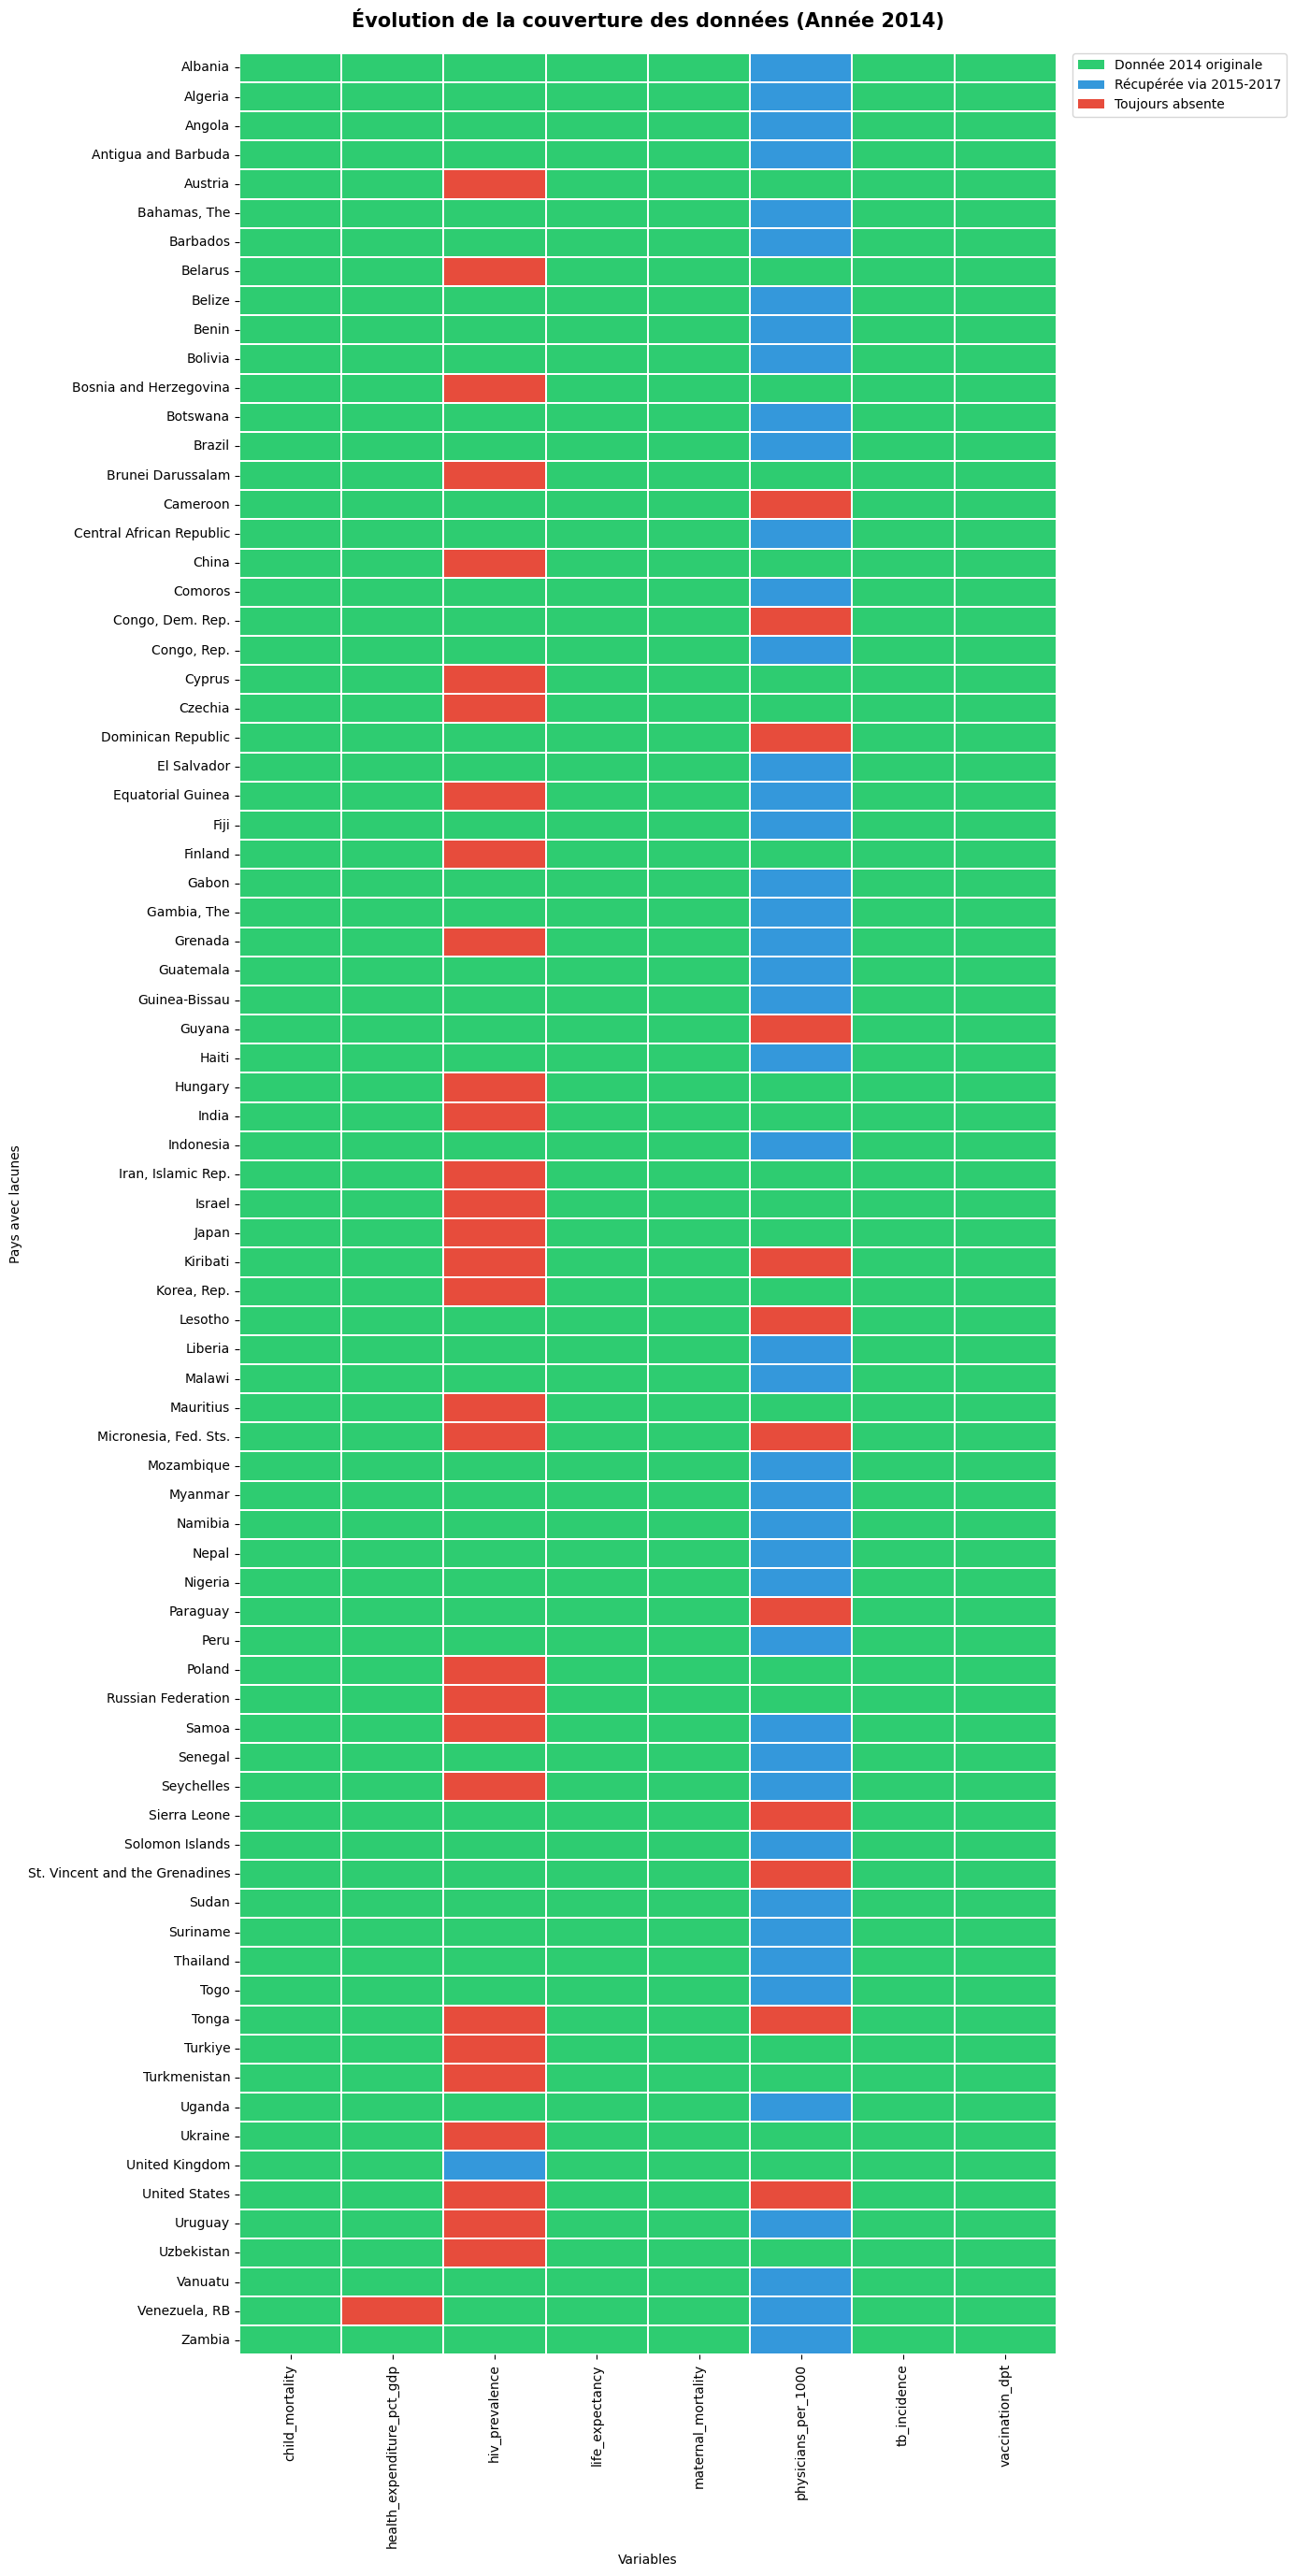

In [28]:
# On pivote le statut pour voir la provenance de chaque donnée
df_pivot_status = df_wdi.pivot(index='Country', columns='Series', values='status')

# Filtrage : On ne garde que les pays qui posaient problème (au moins un NA initial ou final)
df_viz = df_pivot_status[df_pivot_status.max(axis=1) > 0]

# Création de la figure
plt.figure(figsize=(14, max(8, len(df_viz) * 0.35)))

# Palette stricte : Vert (Présent), Bleu (Récupéré), Rouge (NA)
# Le paramètre vmin/vmax assure que 0=Vert, 1=Bleu, 2=Rouge même s'il manque une catégorie
colors = ["#2ecc71", "#3498db", "#e74c3c"]
sns.heatmap(df_viz, cmap=colors, cbar=False, linewidths=0.1, vmin=0, vmax=2)

# Légende
legend_elements = [
    Patch(facecolor='#2ecc71', label='Donnée 2014 originale'),
    Patch(facecolor='#3498db', label='Récupérée via 2015-2017'),
    Patch(facecolor='#e74c3c', label='Toujours absente')
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title("Évolution de la couverture des données (Année 2014)", fontsize=15, weight='bold', pad=20)
plt.ylabel("Pays avec lacunes")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

Certains NA sont toujours persistant,a examiner par EDA

### Merge


In [29]:
df_h14_pivot = df_wdi.pivot(index='iso_code', columns='Series', values='YR2014').reset_index()

#  Fusion  sur la clé iso_code
# On ne prend que les colonnes nécessaires pour éviter les doublons de noms de pays
df_final = df_final.merge(df_h14_pivot, on="iso_code", how="left")

#  Nettoyage final : suppression des colonnes techniques si elles existent
df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|_y')]

df_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,iso_code,child_mortality,health_expenditure_pct_gdp,hiv_prevalence,life_expectancy,maternal_mortality,physicians_per_1000,tb_incidence,vaccination_dpt
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,AFG,74.6,9.528878,0.1,62.260,755.0,0.304,197.0,62.0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,ALB,9.9,6.358841,0.1,78.029,10.0,1.212,16.0,99.0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,DZA,25.4,6.014841,0.1,74.992,80.0,1.819,80.0,95.0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,AGO,64.5,2.156800,1.8,60.396,262.0,0.212,451.0,55.0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,ATG,11.2,5.322183,0.9,76.912,32.0,2.917,3.4,99.0


In [30]:
na_counts = df_final.isnull().sum()

countries_with_na = df_final[df_final.isnull().any(axis=1)]['country'].nunique()

print("--- État des lieux post-récupération et post-merge ---")
print(f"Nombre total de pays avec au moins un NA : {countries_with_na}")
print("\nDétail des NA par indicateur :")
print(na_counts[na_counts > 0])

--- État des lieux post-récupération et post-merge ---
Nombre total de pays avec au moins un NA : 39

Détail des NA par indicateur :
health_expenditure_pct_gdp     1
hiv_prevalence                30
physicians_per_1000           12
dtype: int64


# Santé who datasets

In [31]:
who_conf = sources["sante_who"]
df_who = pd.read_csv(raw_dir / who_conf["file"])
df_who.head(2)


,country_code,year,life_expectancy_who
0,TZA,2018,64.792958
1,DEU,2014,80.759927


La variable "life_expectancy" est deja capté dans sa version wdi,l'information existe et même dans le dataset originel elle y est donc j'estime a ce stade que on peux s'en passer.

#  Pauvreté, Nutrition, Social dataset

Ces pays existent belle et bien mais sous des noms legerement differents

## Valeurs NA

In [ ]:
social_keys = ["social_poverty_mpi", "social_literacy", "social_poverty_2_15", "social_schooling", "social_undernourishment"]
summary = []

for key in social_keys:
    
    conf = sources[key]
    df_tmp = pd.read_excel(raw_dir / conf["file"])
    df_tmp["Country Name"] = df_tmp["Country Name"].replace(country_mapping)
    df_tmp = df_tmp[df_tmp["Country Name"].isin(countries_ref)].set_index("Country Name")
    
    var = conf["variables"][2014]
    
    if 2014 in df_tmp.columns:
        na_list = df_tmp[df_tmp[2014].isna()].index.tolist()
    else:
        na_list = df_tmp.index.tolist()
    
    summary.append({
        "variable": var,
        "nb_na": len(na_list),
        "pays": na_list
    })

pd.DataFrame(summary)

NameError: name 'social_keys' is not defined

## Recherche 2012-2016

In [ ]:

target_var = conf["variables"][2014]

# On définit une fenêtre pour chercher la valeur la plus proche de 2014
years = [y for y in range(2012, 2017) if y in df_tmp.columns]
filled = df_tmp[years].bfill(axis=1).ffill(axis=1)

# Si 2014 est dispo dans les années, on le prend, sinon on prend la colonne la plus proche existante
val_col = 2014 if 2014 in filled.columns else filled.columns[len(filled.columns)//2]

res = filled[[val_col]].rename(columns={val_col: target_var})
social_dfs.append(res)
print(f"{target_var} -> NA finaux : {res.isnull().sum().values[0]} / {len(res)}")

# Jointure de tous les datasets sociaux
for df_s in social_dfs:
    df_final = df_final.merge(df_s, left_on="country", right_index=True, how="left")

AttributeError: 'dict' object has no attribute 'append'